In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

from imblearn.over_sampling import SMOTE

import optuna

import my_metrics
import my_knn

import warnings
warnings.filterwarnings('ignore') 

# 1. Загрузка и предобработка данных

In [42]:
df = pd.read_csv('..\data\smokeEDA.csv')

df

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,NC1.0,CNT,Fire Alarm
0,51142,1654712187,27.450,43.27,48.0,488.0,12844.0,20723,937.586,2.04,2.191,0,False
1,51143,1654712188,27.410,43.54,32.0,457.0,12857.0,20743,937.589,2.16,2.313,1,False
2,51144,1654712189,27.360,43.76,34.0,455.0,12857.0,20747,937.604,2.19,2.350,2,False
3,51145,1654712190,27.320,43.84,29.0,454.0,12858.0,20752,937.610,2.24,2.400,3,True
4,51146,1654712191,27.270,43.98,28.0,456.0,12860.0,20751,937.601,2.26,2.429,4,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42710,60940,1655128362,16.751,54.27,2704.0,400.0,13309.0,19941,936.933,0.80,0.863,4054,False
42711,60941,1655128363,16.770,54.08,2681.0,400.0,13316.0,19943,936.939,0.79,0.853,4055,False
42712,60942,1655128364,16.788,53.91,2746.0,400.0,13313.0,19937,936.945,0.77,0.823,4056,False
42713,60973,1655128395,17.367,56.37,981.0,400.0,13248.0,19785,936.934,0.45,0.480,4087,False


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42715 entries, 0 to 42714
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      42715 non-null  int64  
 1   UTC             42715 non-null  int64  
 2   Temperature[C]  42715 non-null  float64
 3   Humidity[%]     42715 non-null  float64
 4   TVOC[ppb]       42715 non-null  float64
 5   eCO2[ppm]       42715 non-null  float64
 6   Raw H2          42715 non-null  float64
 7   Raw Ethanol     42715 non-null  int64  
 8   Pressure[hPa]   42715 non-null  float64
 9   PM1.0           42715 non-null  float64
 10  NC1.0           42715 non-null  float64
 11  CNT             42715 non-null  int64  
 12  Fire Alarm      42715 non-null  bool   
dtypes: bool(1), float64(8), int64(4)
memory usage: 4.0 MB


In [44]:
X = df.drop('Fire Alarm', axis=1)
y = df['Fire Alarm']

# 2. Разделение данных

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 3. Проверка и балансировка классов ( и Масштабирование)

<Axes: ylabel='Fire Alarm'>

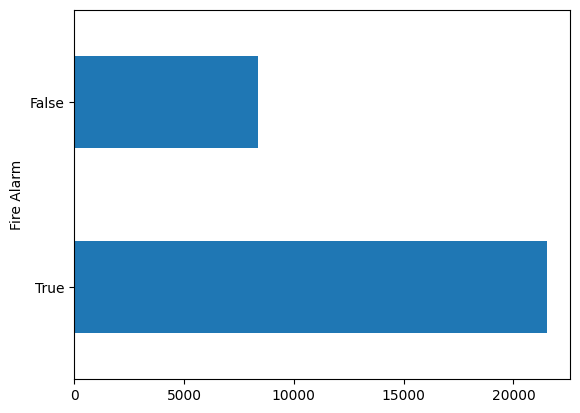

In [46]:
y_train.value_counts().plot.barh()

In [47]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

<Axes: ylabel='Fire Alarm'>

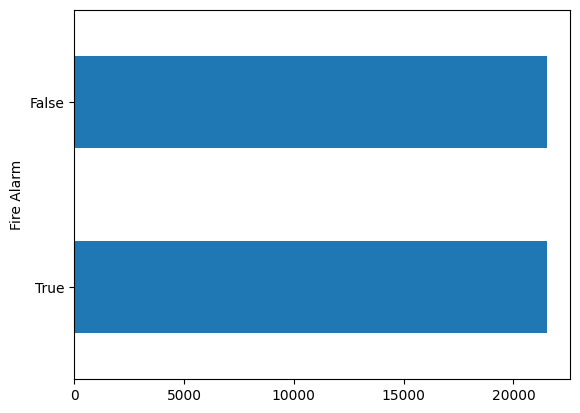

In [48]:
y_resampled.value_counts().plot.barh()

In [49]:
X_train, y_train = X_resampled, y_resampled

In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Обучение классификаторов и подбор гиперпараметров

### Logistic Regression (с RandomizedSearchCV)

In [51]:
models_results = {}

In [52]:
lr = LogisticRegression(max_iter=1000)
param_dist_lr = {
    'C': np.logspace(-4, 4, 20),
    'solver': ['liblinear', 'lbfgs']
}
rs_lr = RandomizedSearchCV(lr, param_dist_lr, n_iter=10, cv=3, scoring='f1', random_state=42, n_jobs=-1)
rs_lr.fit(X_train_scaled, y_train)
print(f"Лучшие параметры LR: {rs_lr.best_params_}")
best_lr = rs_lr.best_estimator_
models_results['LogReg'] = best_lr

Лучшие параметры LR: {'solver': 'lbfgs', 'C': np.float64(0.08858667904100823)}


### kNN (Исследование k и GridSearchCV)


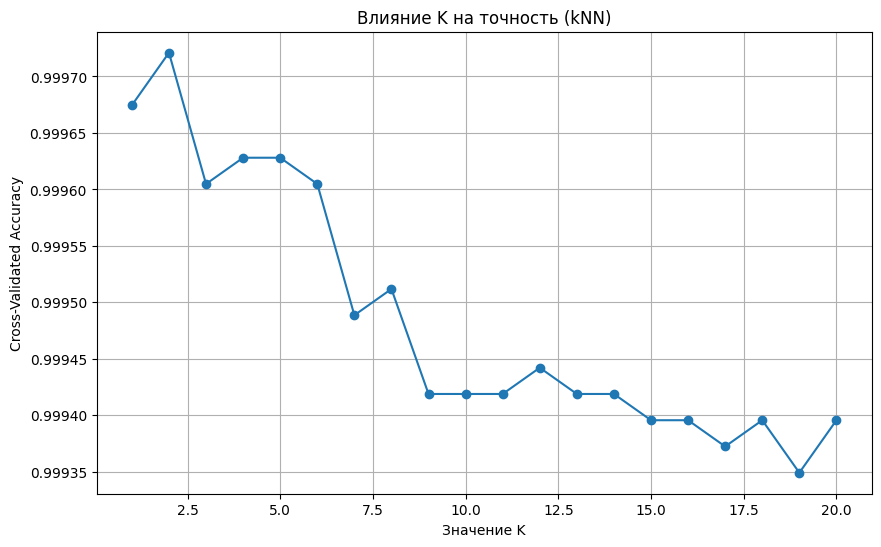

Лучшие параметры kNN: {'metric': 'manhattan', 'n_neighbors': 5}


In [53]:
k_range = range(1, 21)
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=3, scoring='accuracy')
    k_scores.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores, marker='o')
plt.xlabel('Значение K')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Влияние K на точность (kNN)')
plt.grid()
plt.show()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
gs_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=3, scoring='f1', n_jobs=-1)
gs_knn.fit(X_train_scaled, y_train)
print(f"Лучшие параметры kNN: {gs_knn.best_params_}")
best_knn = gs_knn.best_estimator_
models_results['kNN'] = best_knn

### Naive Bayes (Gaussian)

In [54]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
models_results['NaiveBayes'] = nb

### SVM (с использованием Optuna)

In [55]:
def objective_svm(trial):
    kernel = trial.suggest_categorical('kernel', ['linear', 'sigmoid'])
    c = trial.suggest_loguniform('C', 1e-3, 1e2)
    gamma = 'scale'
    if kernel != 'linear':
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    
    idx = np.random.choice(len(X_train_scaled), size=min(len(X_train_scaled), 2000), replace=False)
    X_sub, y_sub = X_train_scaled[idx], y_train.iloc[idx]
    
    clf = SVC(kernel=kernel, C=c, gamma=gamma, probability=True)
    score = cross_val_score(clf, X_sub, y_sub, n_jobs=-1, cv=3).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective_svm, n_trials=10)
print(f"Лучшие параметры SVM (Optuna): {study.best_params}")

best_params_svm = study.best_params
best_svm = SVC(**best_params_svm, probability=True)
best_svm.fit(X_train_scaled, y_train)
models_results['SVM'] = best_svm

[I 2026-03-06 08:57:36,213] A new study created in memory with name: no-name-92f157e6-b514-449d-84fe-af4a46bf024f
[I 2026-03-06 08:57:36,334] Trial 0 finished with value: 0.9390109749929839 and parameters: {'kernel': 'linear', 'C': 0.0036788435786386615}. Best is trial 0 with value: 0.9390109749929839.
[I 2026-03-06 08:57:36,436] Trial 1 finished with value: 0.9375064719892306 and parameters: {'kernel': 'linear', 'C': 0.0032064590704703696}. Best is trial 0 with value: 0.9390109749929839.
[I 2026-03-06 08:57:36,597] Trial 2 finished with value: 0.9049994522258391 and parameters: {'kernel': 'sigmoid', 'C': 0.10003634079172381, 'gamma': 'auto'}. Best is trial 0 with value: 0.9390109749929839.
[I 2026-03-06 08:57:36,645] Trial 3 finished with value: 1.0 and parameters: {'kernel': 'linear', 'C': 16.326905352455118}. Best is trial 3 with value: 1.0.
[I 2026-03-06 08:57:36,836] Trial 4 finished with value: 0.9155024589807198 and parameters: {'kernel': 'sigmoid', 'C': 0.028246764292077876, 'g

Лучшие параметры SVM (Optuna): {'kernel': 'linear', 'C': 16.326905352455118}


# 5. Оценка моделей и Визуализация результатов

In [56]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.plot(train_sizes, train_mean, label='Training score', color='blue')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, test_mean, label='Cross-validation score', color='red')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
    
    plt.title(f'Learning Curve: {title}')
    plt.xlabel('Training Examples')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid()
    plt.show()



Оценка модели: LogReg
SKLEARN Метрики:
Accuracy: 0.9995
Precision: 0.9996
Recall: 0.9998
F1 Score: 0.9997
ROC AUC: 1.0000


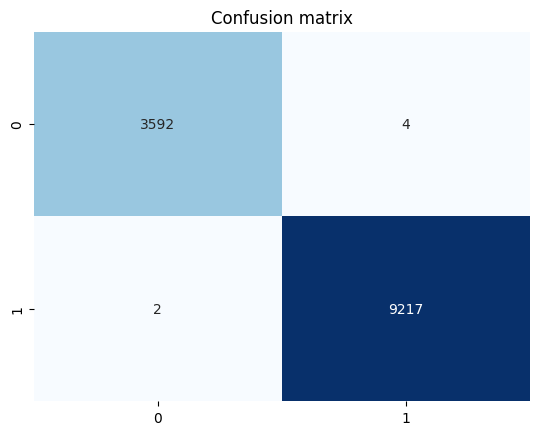

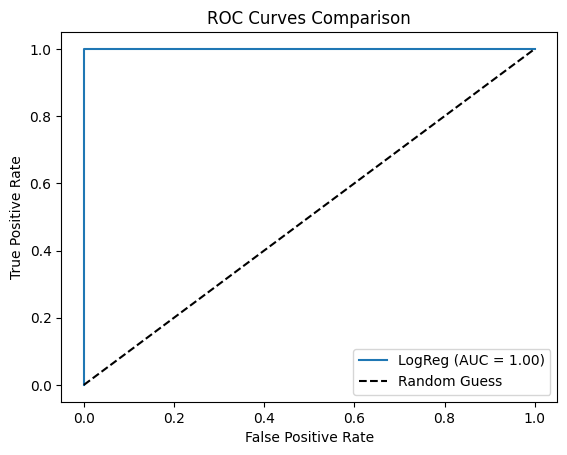


Оценка модели: kNN
SKLEARN Метрики:
Accuracy: 0.9998
Precision: 0.9999
Recall: 0.9999
F1 Score: 0.9999
ROC AUC: 1.0000


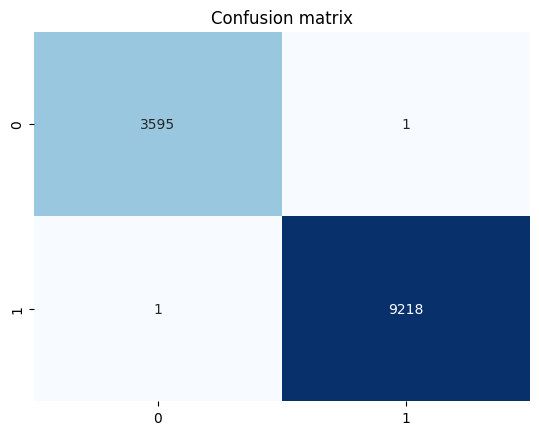

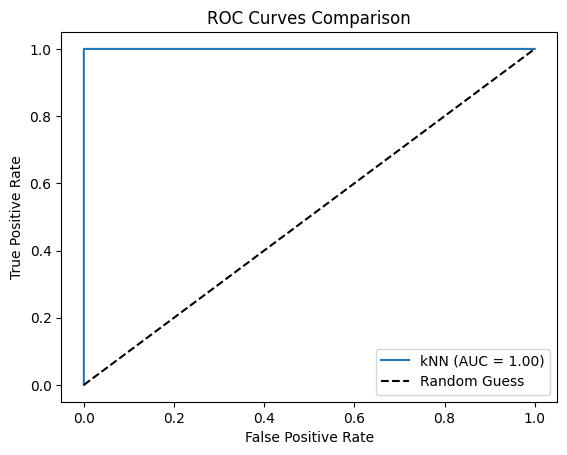


Оценка модели: NaiveBayes
SKLEARN Метрики:
Accuracy: 0.9932
Precision: 0.9971
Recall: 0.9935
F1 Score: 0.9953
ROC AUC: 0.9973


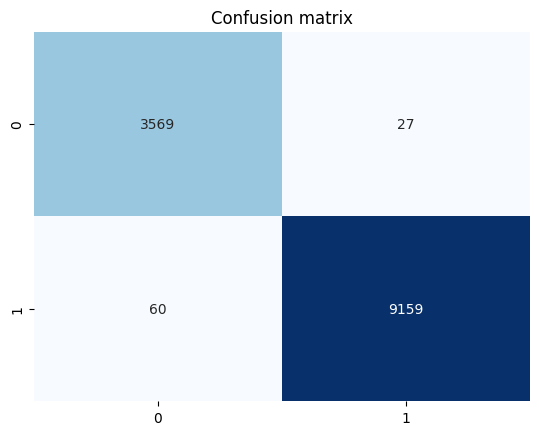

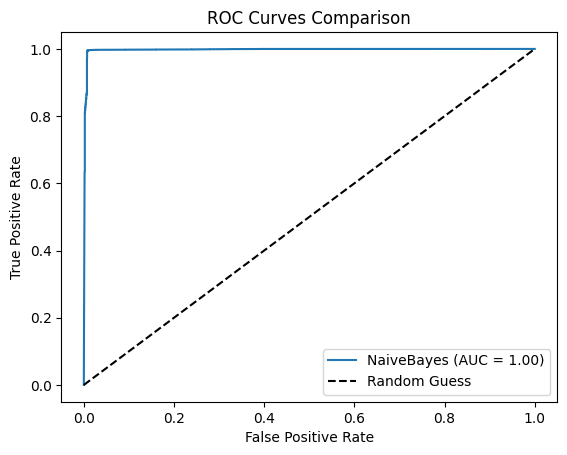


Оценка модели: SVM
SKLEARN Метрики:
Accuracy: 0.9998
Precision: 0.9997
Recall: 1.0000
F1 Score: 0.9998
ROC AUC: 1.0000


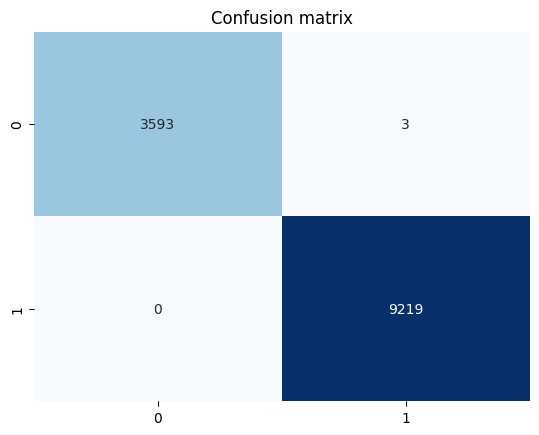

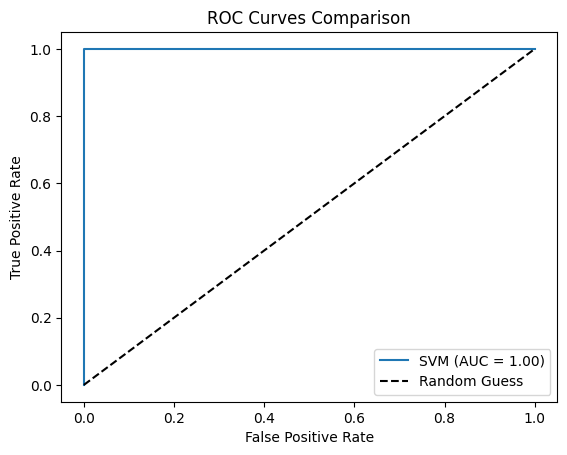

In [57]:

for name, model in models_results.items():
    print(f"\nОценка модели: {name}")
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None
    
    print("SKLEARN Метрики:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}" if y_proba is not None else "ROC AUC: N/A")
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, cmap='Blues')
    plt.title('Confusion matrix')
    plt.show()

    plt.figure()
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_proba):.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Comparison')
    plt.legend()
    plt.show()

    #plot_learning_curve(model, X_train_scaled, y_train, name)

# 6. Тестирование пользовательских библиотек

In [58]:
y_pred_lr = best_lr.predict(X_test_scaled)
print(f"Custom Accuracy: {my_metrics.accuracy(y_test, y_pred_lr):.4f}")
print(f"Custom Precision: {my_metrics.precision(y_test, y_pred_lr):.4f}")
print(f"Custom Recall: {my_metrics.recall(y_test, y_pred_lr):.4f}")
print(f"Custom F1: {my_metrics.f1_score(y_test, y_pred_lr):.4f}")
print(f"Custom CM: {my_metrics.calculate_confusion_matrix(y_test, y_pred_lr)}")

Custom Accuracy: 0.9995
Custom Precision: 0.9996
Custom Recall: 0.9998
Custom F1: 0.9997
Custom CM: [[3592, 4], [2, 9217]]


In [59]:
subset_size = 500
X_train_sub = X_train_scaled[:subset_size]
y_train_sub = y_train.iloc[:subset_size].values
X_test_sub = X_test_scaled[:100] 

my_knn_clf = my_knn.MyKNNClassifier(k=5)
my_knn_clf.fit(X_train_sub, y_train_sub)
my_pred = my_knn_clf.predict(X_test_sub)
print("\nCustom kNN prediction sample:", my_pred[:10])


Custom kNN prediction sample: [ True  True  True  True  True  True  True  True False  True]
